In [1]:
import numpy as np
import matplotlib.pyplot as plt

def extraction(file):
    seqs = {}
    current_id = ""
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            current_id = line[1:]
            seqs[current_id] = ""
        else:
            seqs[current_id] += line
        # truncate each sequence to first 40 aa
        for k in seqs:
            seqs[k] = seqs[k][:40]
    return seqs

aa_list = list("ACDEFGHIKLMNPQRSTVWY")


# read FASTA files 
with open("pos_cluster-results_rep_seq.fasta", 'r') as pos_file:
    pos = extraction(pos_file)
with open("neg_cluster-results_rep_seq.fasta", 'r') as neg_file:
    neg = extraction(neg_file)
    
# Create a matrix for amino acid counts

matrix_pos = np.zeros((len(pos), len(aa_list)))
matrix_neg = np.zeros((len(neg), len(aa_list)))

for i, seq in enumerate(pos.values()):
    for j, aa in enumerate(aa_list):
        matrix_pos[i, j] = seq.count(aa)
        
for i, seq in enumerate(neg.values()):
    for j, aa in enumerate(aa_list):
        matrix_neg[i, j] = seq.count(aa)

#  count amino acids in pos+neg together 
all_seqs = list(pos.values()) + list(neg.values())
all_seqs = "".join(all_seqs)  # concatenate everything
total_len = len(all_seqs)

obs_freq = []
for aa in aa_list:
    obs_freq.append(all_seqs.count(aa) / total_len * 100)  # percentage

# --- SwissProt composition ---
swissprot_comp = {
    "L": 9.65, "A": 8.26, "G": 7.07, "V": 6.86, "E": 6.72, "S": 6.66,
    "I": 5.91, "K": 5.80, "R": 5.53, "D": 5.46, "T": 5.37, "P": 4.75,
    "N": 4.06, "Q": 3.93, "F": 3.87, "Y": 2.92, "M": 2.41, "H": 2.28,
    "C": 1.39, "W": 1.11
}
swiss_freq = [swissprot_comp[aa] for aa in aa_list]

In [2]:
def amino_acid_composition(seq_dic, truncate=40):
    aa_list = list("ACDEFGHIKLMNPQRSTVWY")
    features = {}
    for seq_id, seq in seq_dic.items():
        seq = seq[:truncate]
        counts = []
        if len(seq) > 0:
            for aa in aa_list:
                count=seq.count(aa)
                freq= count/len(seq)
                counts.append(freq)
        features[seq_id] = counts
    return features
positive_aa= amino_acid_composition(pos)
negative_aa= amino_acid_composition(neg)

In [3]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData

def hydro(seq_dic, window_size=7):
    profiles = {}
    
    for seq_id, sequence in seq_dic.items():
        #replace the X residues in the FASTA with a None value
        
        clean_seq = sequence.replace("X", "G")

        if len(clean_seq) < window_size:
            continue  # skip too-short sequences

        seq_obj = ProteinAnalysis(clean_seq)
        kd = seq_obj.protein_scale(ProtParamData.kd, window_size)
        profiles[seq_id] = kd

    return profiles
positive_hydro= hydro(pos)
negative_hydro= hydro (neg)

In [4]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
def secondary_str (seq_dic):
    results= {}
    for seq_id, sequence in seq_dic.items():
        secondary_str = ProteinAnalysis(sequence)
        helix, turn, sheet = secondary_str.secondary_structure_fraction() 
        results[seq_id] = [helix, turn, sheet]
    return results
positive_str= secondary_str(pos)
negative_str= secondary_str(neg)


In [5]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import matplotlib.pyplot as plt

def get_charges(seq_dic, ph=7.0):
    seq_ids = list(seq_dic.keys())
    pI_values = []
    charge_values = []
    
    for seq_id in seq_ids:
        seq = seq_dic[seq_id]
        pa = ProteinAnalysis(seq)
        pI_values.append(pa.isoelectric_point())
        charge_values.append(pa.charge_at_pH(ph))
    
    return np.array(pI_values), np.array(charge_values)

# Compute for positives and negatives 
pI_pos, charge_pos = get_charges(pos, ph=7.0)
pI_neg, charge_neg = get_charges(neg, ph=7.0)

# Select first 100 for plotting 
n_to_plot = 100
subset_pos = charge_pos[:n_to_plot]
subset_neg = charge_neg[:n_to_plot]

In [6]:
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis

transmembrane_tendency_scale = {
    'A':  0.380, 'R': -2.570, 'N': -1.620, 'D': -3.270, 'C': -0.300,
    'Q': -1.840, 'E': -2.900, 'G': -0.190, 'H': -1.440, 'I':  1.970,
    'L':  1.820, 'K': -3.460, 'M':  1.400, 'F':  1.980, 'P': -1.440,
    'S': -0.530, 'T': -0.320, 'W':  1.530, 'Y':  0.490, 'V':  1.460
}

def transmembrane(seq_dict, window_size=7):
    features = {}

    for seq_id, sequence in seq_dict.items():
        clean_seq = sequence.replace("X", "G")

        if len(clean_seq) < window_size:
            features[seq_id] = [np.nan, np.nan]
            continue

        try:
            seq_obj = ProteinAnalysis(clean_seq)
            profile = seq_obj.protein_scale(transmembrane_tendency_scale, window_size)

            if profile:
                max_tm = np.max(profile)
                avg_tm = np.mean(profile)
                features[seq_id] = [max_tm, avg_tm]
            else:
                features[seq_id] = [np.nan, np.nan]

        except Exception as e:
            print(f"Error processing sequence {seq_id}: {e}")
            features[seq_id] = [np.nan, np.nan]

    return features

In [7]:
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis

refractivity_scale = {
    'A':  4.340, 'R': 26.660, 'N': 13.280, 'D': 12.000, 'C': 35.770,
    'Q': 17.560, 'E': 17.260, 'G':  0.000, 'H': 21.810, 'I': 19.060,
    'L': 18.780, 'K': 21.290, 'M': 21.640, 'F': 29.400, 'P': 10.930,
    'S':  6.350, 'T': 11.010, 'W': 42.530, 'Y': 31.530, 'V': 13.920
}

def refractivity(sequence_dict, scale, window_size=7):
    features = {}

    for seq_id, sequence in sequence_dict.items():
        clean_seq = sequence.replace("X", "G")

        if len(clean_seq) < window_size:
            features[seq_id] = [np.nan, np.nan]
            continue

        try:
            seq_obj = ProteinAnalysis(clean_seq)
            profile = seq_obj.protein_scale(scale, window_size)

            if profile:
                max_val = np.max(profile)
                avg_val = np.mean(profile)
                features[seq_id] = [max_val, avg_val]
            else:
                features[seq_id] = [np.nan, np.nan]

        except Exception as e:
            print(f"Error processing sequence {seq_id}: {e}")
            features[seq_id] = [np.nan, np.nan]

    return features

In [8]:
import numpy as np

def build_feature_matrix(positive_hydro, negative_hydro,
                         positive_str, negative_str,
                         pI_pos, charge_pos,
                         pI_neg, charge_neg):
    """
    Combine physicochemical features (hydrophobicity, secondary structure,
    pI, charge) into a unified feature matrix (X) and target vector (y).
    """

    X = []
    y = []

    # --- Positive class (label = 1) ---
    for i, seq_id in enumerate(positive_str.keys()):
        # mean hydrophobicity
        hydro_value = np.mean(positive_hydro[seq_id])
        # secondary structure: helix, turn, sheet
        helix, turn, sheet = positive_str[seq_id]
        # charge and isoelectric point
        pI = pI_pos[i]
        charge = charge_pos[i]

        # one feature vector per sequence
        X.append([hydro_value, helix, turn, sheet, pI, charge])
        y.append(1)

    # --- Negative class (label = 0) ---
    for i, seq_id in enumerate(negative_str.keys()):
        hydro_value = np.mean(negative_hydro[seq_id])
        helix, turn, sheet = negative_str[seq_id]
        pI = pI_neg[i]
        charge = charge_neg[i]

        X.append([hydro_value, helix, turn, sheet, pI, charge])
        y.append(0)

    # convert to numpy arrays
    X = np.array(X)
    y = np.array(y)

    return X, y


# Example usage:
X, y = build_feature_matrix(
    positive_hydro, negative_hydro,
    positive_str, negative_str,
    pI_pos, charge_pos,
    pI_neg, charge_neg
)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("First 5 samples:\n", X[:5])
print("First 5 labels:", y[:5])


Feature matrix shape: (10026, 6)
Target vector shape: (10026,)
First 5 samples:
 [[ 0.52394958  0.325       0.275       0.45        9.30338421  2.56373089]
 [ 0.71890756  0.35        0.25        0.4         7.86148434  0.58135556]
 [ 0.47857143  0.45        0.325       0.3        11.82390461  2.5897204 ]
 [ 0.40168067  0.5         0.25        0.3        11.55526485  4.57840035]
 [ 0.28529412  0.375       0.2         0.425       7.67232037  0.46840239]]
First 5 labels: [1 1 1 1 1]


In [9]:
import numpy as np
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData

#  Scales 
transmembrane_tendency_scale = {
    'A':  0.380, 'R': -2.570, 'N': -1.620, 'D': -3.270, 'C': -0.300,
    'Q': -1.840, 'E': -2.900, 'G': -0.190, 'H': -1.440, 'I':  1.970,
    'L':  1.820, 'K': -3.460, 'M':  1.400, 'F':  1.980, 'P': -1.440,
    'S': -0.530, 'T': -0.320, 'W':  1.530, 'Y':  0.490, 'V':  1.460
}

refractivity_scale = {
    'A':  4.340, 'R': 26.660, 'N': 13.280, 'D': 12.000, 'C': 35.770,
    'Q': 17.560, 'E': 17.260, 'G':  0.000, 'H': 21.810, 'I': 19.060,
    'L': 18.780, 'K': 21.290, 'M': 21.640, 'F': 29.400, 'P': 10.930,
    'S':  6.350, 'T': 11.010, 'W': 42.530, 'Y': 31.530, 'V': 13.920
}

#  Amino acid composition 
def amino_acid_composition(sequence, truncate=40):
    aa_list = list("ACDEFGHIKLMNPQRSTVWY")
    sequence = sequence[:truncate]
    counts = [sequence.count(aa) / len(sequence) if len(sequence) > 0 else 0 for aa in aa_list]
    return counts

#  Hydrophobicity profile (Kyte-Doolittle) 
def hydro(sequence, window_size=7):
    clean_seq = sequence.replace("X", "G")
    pa = ProteinAnalysis(clean_seq)
    profile = pa.protein_scale(ProtParamData.kd, window_size)
    return [np.mean(profile), np.max(profile), np.std(profile)]

#  Secondary structure fractions 
def secondary_str(sequence):
    pa = ProteinAnalysis(sequence)
    helix, turn, sheet = pa.secondary_structure_fraction()
    return [helix, turn, sheet]

#  Transmembrane and refractivity profiles 
def scale_features(sequence, scale, window_size=7):
    clean_seq = sequence.replace("X", "G")
    pa = ProteinAnalysis(clean_seq)
    profile = pa.protein_scale(scale, window_size)
    return [np.mean(profile), np.max(profile)]

#  Main feature matrix builder 
def build_feature_matrix(pos_dict, neg_dict):
    """
    Build full feature matrix (X) and labels (y) for positive/negative sequence sets.
    """
    X = []
    y = []
    seq_ids = []

    for label, seq_dict in zip([1, 0], [pos_dict, neg_dict]):
        for seq_id, seq in seq_dict.items():
            try:
                # Basic features
                aa = amino_acid_composition(seq)
                hydro_feats = hydro(seq)
                ss_feats = secondary_str(seq)
                pa = ProteinAnalysis(seq)
                pI = pa.isoelectric_point()
                charge = pa.charge_at_pH(7.0)
                tm_feats = scale_features(seq, transmembrane_tendency_scale)
                refr_feats = scale_features(seq, refractivity_scale)

                # Combine all features into one vector
                feature_vector = np.concatenate([
                    aa,
                    hydro_feats,
                    ss_feats,
                    [pI, charge],
                    tm_feats,
                    refr_feats
                ])
                X.append(feature_vector)
                y.append(label)
                seq_ids.append(seq_id)

            except Exception as e:
                print(f"Error processing {seq_id}: {e}")

    # Convert to DataFrame
    aa_names = [f"AA_{aa}" for aa in "ACDEFGHIKLMNPQRSTVWY"]
    feature_names = aa_names + [
        "hydro_mean", "hydro_max", "hydro_std",
        "helix", "turn", "sheet",
        "pI", "charge",
        "tm_mean", "tm_max",
        "refr_mean", "refr_max"
    ]

    df = pd.DataFrame(X, columns=feature_names)
    df["label"] = y
    df["seq_id"] = seq_ids

    return df, feature_names
    
df, feature_names = build_feature_matrix(pos, neg)

print(df.shape)
print(df.head())
    

(10026, 34)
    AA_A   AA_C   AA_D   AA_E  AA_F   AA_G   AA_H  AA_I   AA_K   AA_L  ...  \
0  0.050  0.050  0.000  0.000  0.05  0.075  0.025  0.05  0.075  0.175  ...   
1  0.075  0.050  0.000  0.075  0.05  0.125  0.025  0.05  0.000  0.175  ...   
2  0.200  0.000  0.050  0.000  0.00  0.150  0.025  0.00  0.000  0.225  ...   
3  0.200  0.025  0.000  0.025  0.00  0.100  0.025  0.00  0.050  0.200  ...   
4  0.075  0.075  0.025  0.050  0.05  0.050  0.000  0.05  0.100  0.125  ...   

    turn  sheet         pI    charge   tm_mean    tm_max  refr_mean  \
0  0.275  0.450   9.303384  2.563731  0.143739  1.240000  16.946176   
1  0.250  0.400   7.861484  0.581356  0.050420  1.528571  15.426218   
2  0.325  0.300  11.823905  2.589720 -0.018025  1.257143  12.098529   
3  0.250  0.300  11.555265  4.578400 -0.102857  1.327143  14.479538   
4  0.200  0.425   7.672320  0.468402 -0.201092  0.987143  18.553739   

    refr_max  label  seq_id  
0  23.790000      1  O43155  
1  20.991429      1  O43866  
2 


 Fold 1/5 
Train: ['fold_ac', 'fold_ad', 'fold_ae'], Val: fold_ab, Test: fold_aa
Top 10 features by Gini importance:
      feature  importance
0      tm_max    0.191105
1   hydro_max    0.163500
2     tm_mean    0.110348
3  hydro_mean    0.108681
4   hydro_std    0.093944
5       sheet    0.036881
6   refr_mean    0.022565
7        AA_L    0.020826
8        AA_A    0.019087
9      charge    0.019036


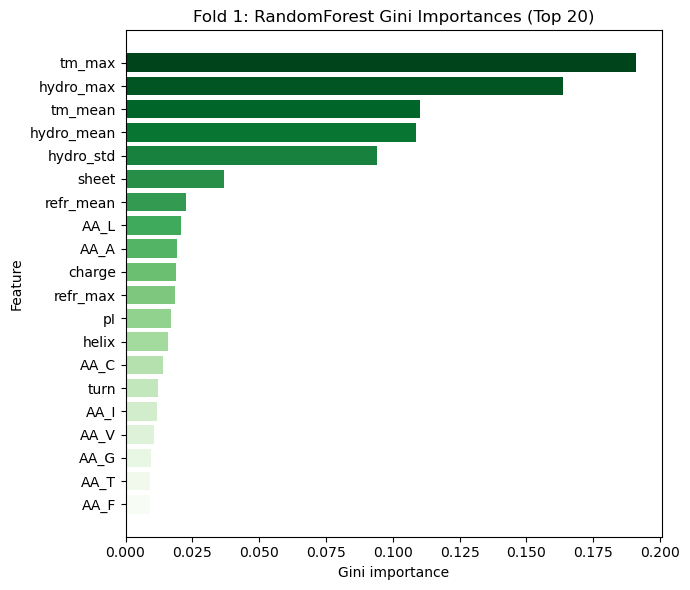

Best k = 22, Val Acc = 0.958


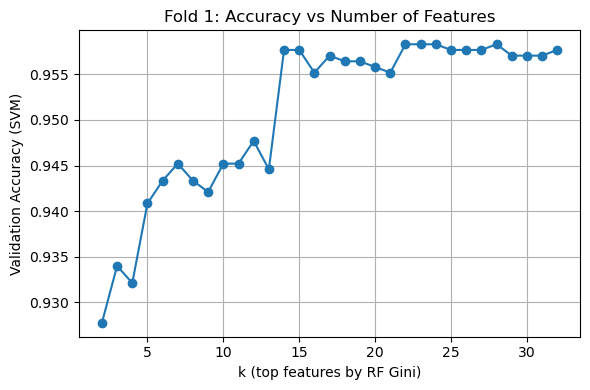

Best params for selected features: {'C': 10.0, 'gamma': 'scale'}, val_acc=0.958

Fold 1 results:
  All features -> Acc=0.944, F1=0.735, MCC=0.705
  Selected (22) -> Acc=0.945, F1=0.747, MCC=0.717


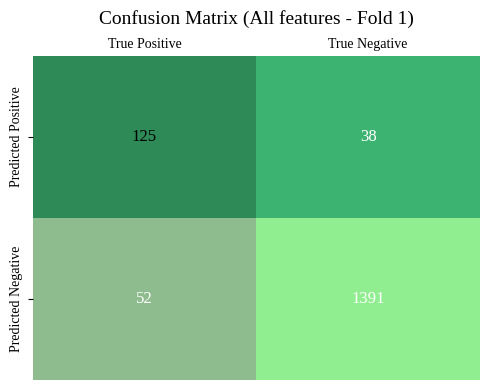

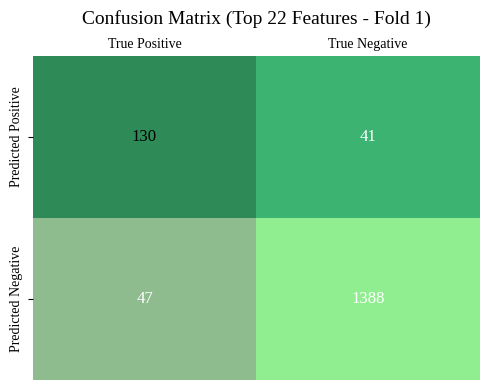


 Fold 2/5 
Train: ['fold_aa', 'fold_ad', 'fold_ae'], Val: fold_ac, Test: fold_ab
Top 10 features by Gini importance:
      feature  importance
0      tm_max    0.190328
1   hydro_max    0.158535
2  hydro_mean    0.111204
3     tm_mean    0.109789
4   hydro_std    0.083095
5       sheet    0.037816
6      charge    0.022364
7   refr_mean    0.021264
8        AA_L    0.020933
9    refr_max    0.018678


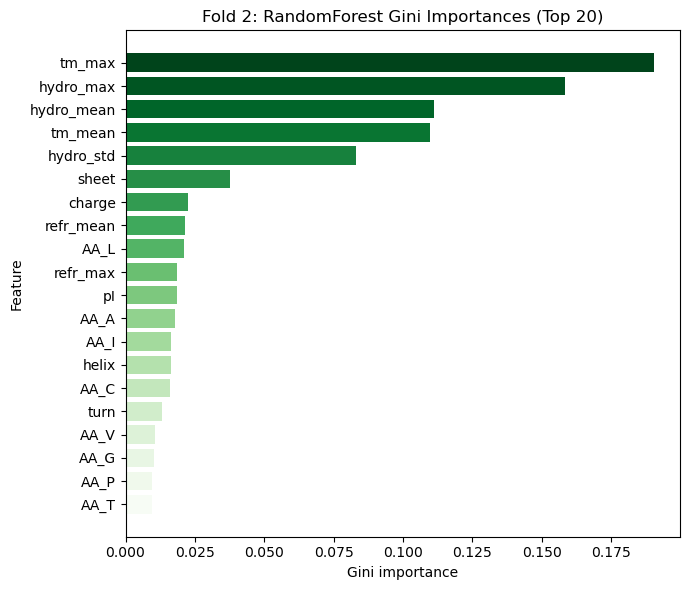

Best k = 19, Val Acc = 0.966


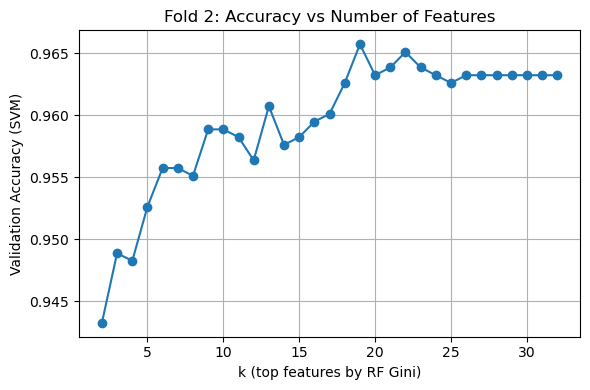

Best params for selected features: {'C': 1.0, 'gamma': 'scale'}, val_acc=0.966

Fold 2 results:
  All features -> Acc=0.956, F1=0.788, MCC=0.764
  Selected (19) -> Acc=0.953, F1=0.775, MCC=0.749


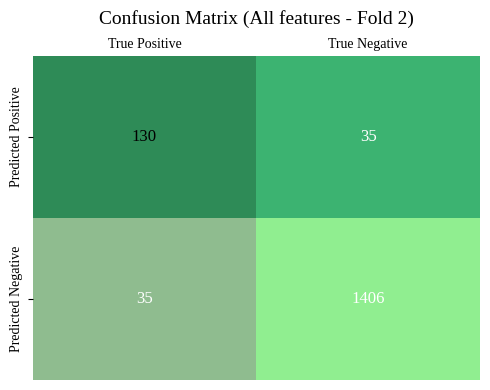

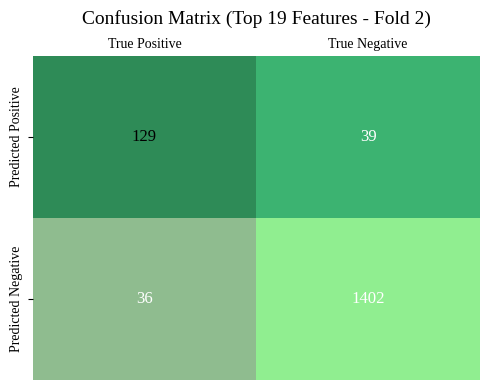


 Fold 3/5 
Train: ['fold_aa', 'fold_ab', 'fold_ae'], Val: fold_ad, Test: fold_ac
Top 10 features by Gini importance:
      feature  importance
0      tm_max    0.186364
1   hydro_max    0.157692
2     tm_mean    0.111515
3  hydro_mean    0.102690
4   hydro_std    0.079679
5       sheet    0.037621
6      charge    0.023951
7        AA_L    0.023656
8          pI    0.023575
9   refr_mean    0.021697


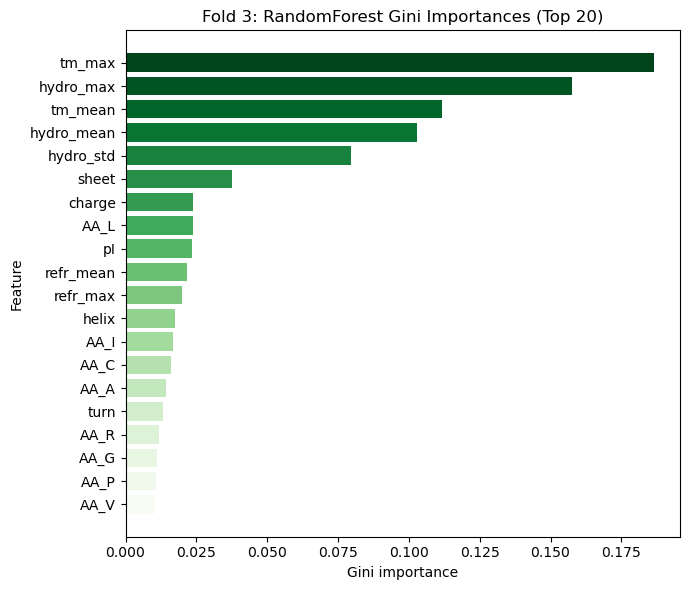

Best k = 29, Val Acc = 0.959


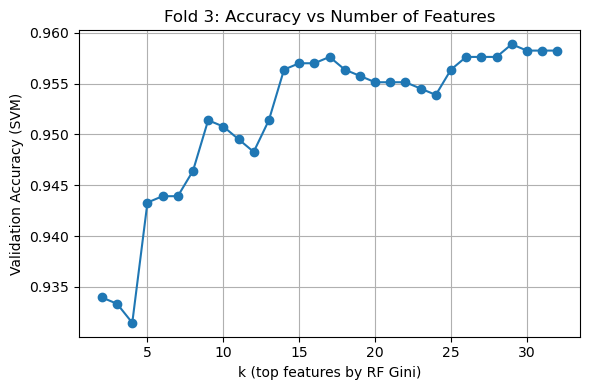

Best params for selected features: {'C': 1.0, 'gamma': 'scale'}, val_acc=0.959

Fold 3 results:
  All features -> Acc=0.964, F1=0.838, MCC=0.818
  Selected (29) -> Acc=0.962, F1=0.829, MCC=0.808


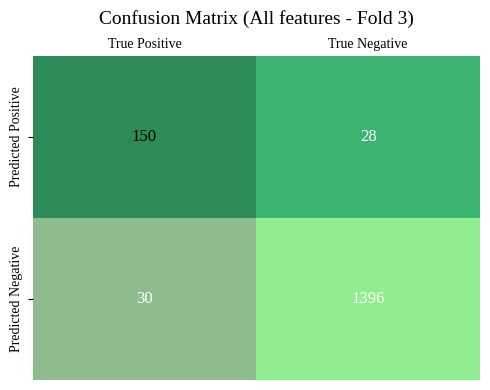

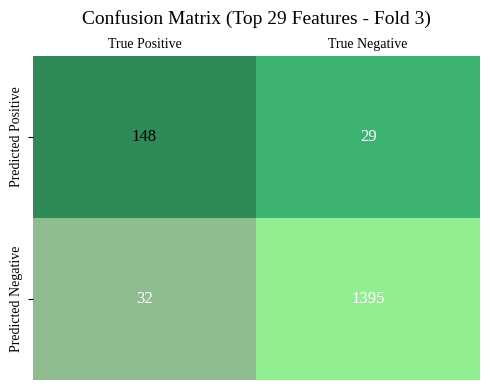


 Fold 4/5 
Train: ['fold_aa', 'fold_ab', 'fold_ac'], Val: fold_ae, Test: fold_ad
Top 10 features by Gini importance:
      feature  importance
0      tm_max    0.188666
1   hydro_max    0.165204
2  hydro_mean    0.109605
3     tm_mean    0.107896
4   hydro_std    0.086384
5       sheet    0.034136
6        AA_L    0.023722
7          pI    0.022600
8      charge    0.021800
9   refr_mean    0.020581


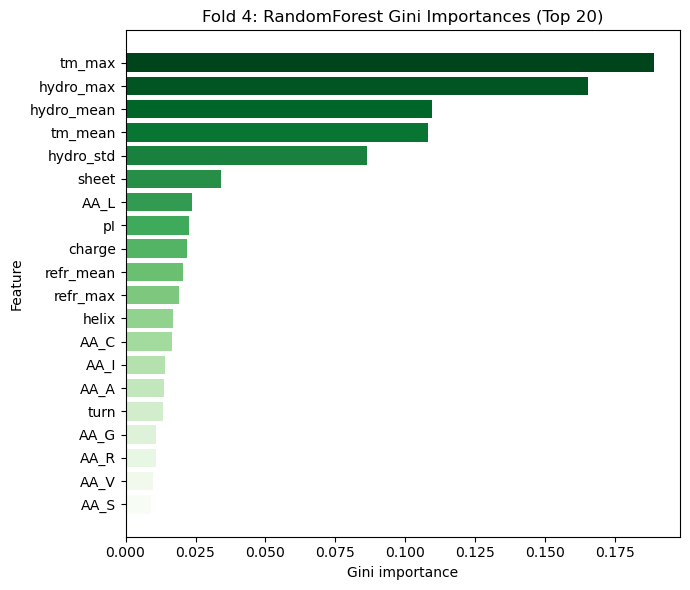

Best k = 24, Val Acc = 0.947


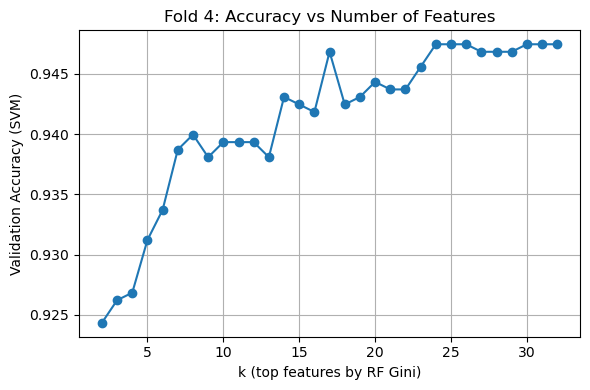

Best params for selected features: {'C': 1.0, 'gamma': 'scale'}, val_acc=0.949

Fold 4 results:
  All features -> Acc=0.956, F1=0.805, MCC=0.782
  Selected (24) -> Acc=0.958, F1=0.818, MCC=0.797


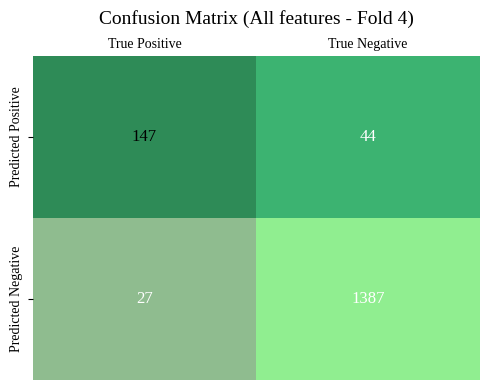

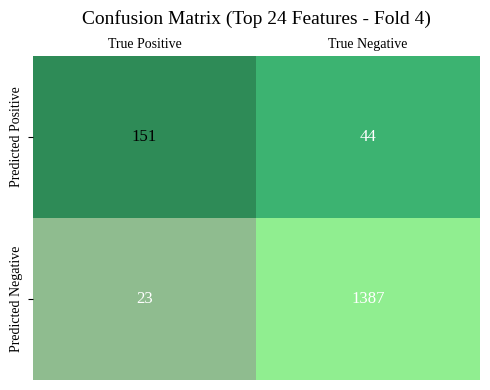


 Fold 5/5 
Train: ['fold_ab', 'fold_ac', 'fold_ad'], Val: fold_aa, Test: fold_ae
Top 10 features by Gini importance:
      feature  importance
0      tm_max    0.192415
1   hydro_max    0.166253
2  hydro_mean    0.108604
3     tm_mean    0.102117
4   hydro_std    0.091702
5       sheet    0.032527
6   refr_mean    0.023691
7      charge    0.022779
8        AA_L    0.022351
9          pI    0.020423


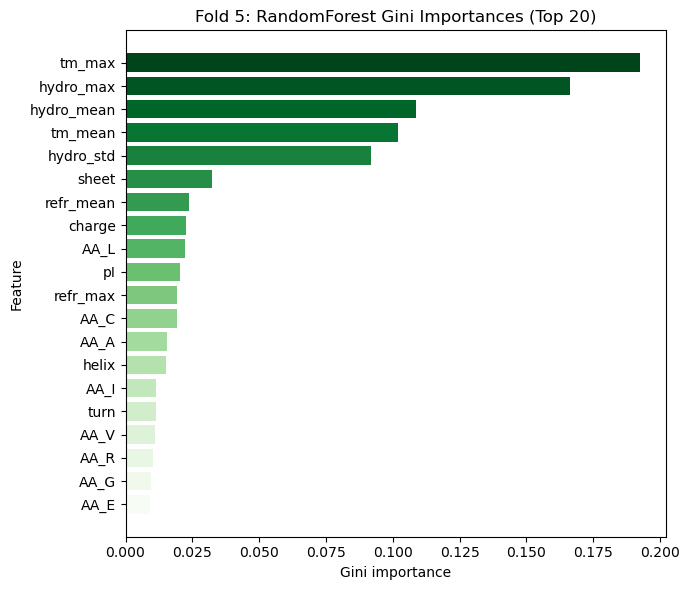

Best k = 24, Val Acc = 0.951


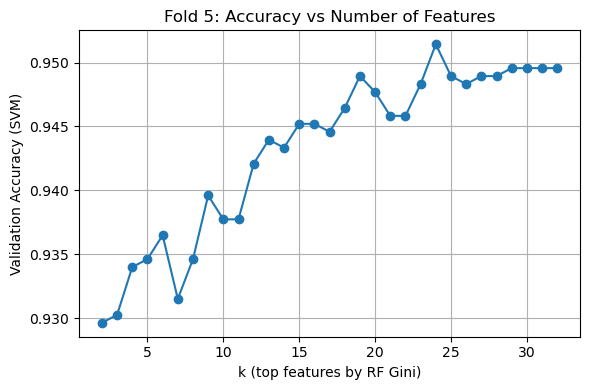

Best params for selected features: {'C': 10.0, 'gamma': 'scale'}, val_acc=0.951

Fold 5 results:
  All features -> Acc=0.949, F1=0.767, MCC=0.738
  Selected (24) -> Acc=0.946, F1=0.749, MCC=0.719


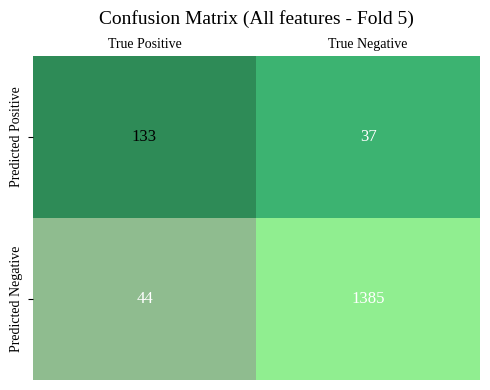

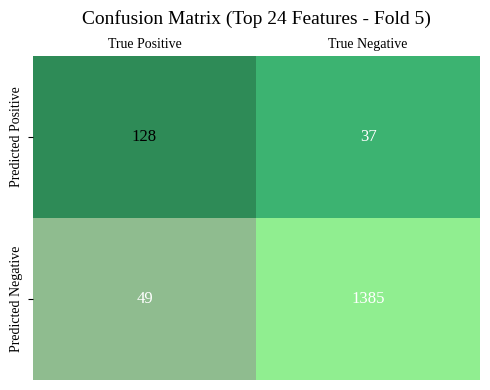


--------SUMMARY CV --------
   fold   k   acc_all   acc_sel    f1_all    f1_sel   mcc_all   mcc_sel
0     1  22  0.943960  0.945205  0.735294  0.747126  0.704764  0.716544
1     2  19  0.956413  0.953300  0.787879  0.774775  0.763590  0.748764
2     3  29  0.963840  0.961970  0.837989  0.829132  0.817655  0.807773
3     4  24  0.955763  0.958255  0.805479  0.818428  0.781664  0.796578
4     5  24  0.949343  0.946216  0.766571  0.748538  0.738362  0.719022

Average Performance:
acc_all    0.953864
acc_sel    0.952990
f1_all     0.786642
f1_sel     0.783600
mcc_all    0.761207
mcc_sel    0.757737
dtype: float64


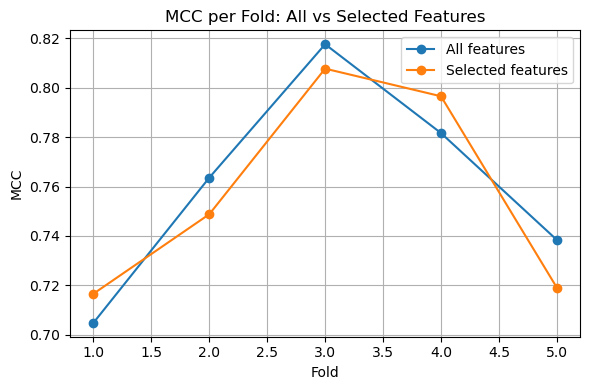

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.cm as cm

# testing on different kernels 
def svm_pipeline(C, gamma, kernel="linear", degree=3, coef0=0.0):
    return SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, coef0=coef0, random_state=42)

# Custom confusion matrix plot
def plot_confusion_matrix_custom(y_true, y_pred, round_num, features, tag= "" ):
    cm_ = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm_.ravel()
    plot_cm = np.array([[TP, FP],
                        [FN, TN]])

    cell_colors = np.array([['seagreen', 'mediumseagreen'], ['darkseagreen', 'lightgreen']])

    fig, ax = plt.subplots(figsize=(5, 4))
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c],
                                       edgecolor=None, linewidth=0))
            text_color = 'black' if (r, c) == (0, 0) else 'white'
            ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', which='both', length=0)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'],
                       rotation=90, va='center', fontname='Liberation Serif')

    ax.set_title(f'Confusion Matrix ({features} - Fold {round_num})',
                 fontsize=14, fontfamily='Liberation Serif', pad=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.tight_layout()

    safe_tag = tag.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"confusion_matrix_fold{round_num}_{safe_tag}.png", dpi=200, bbox_inches='tight')
    plt.show()
    

# Config
best_params_base = {"C": 10, "gamma": 0.1}
C_grid = [0.1, 1.0, 10.0, 100.0]
gamma_grid = ["scale", 0.01, 0.1, 1.0]

fold_metrics = []
fold_conf_mats = []
k_curves = []

fold_files = ["fold_aa", "fold_ab", "fold_ac", "fold_ad", "fold_ae"]

fold_data = {}

for file_name in fold_files:
    with open(file_name, 'r') as f:
        seq_ids = [line.strip() for line in f if line.strip()]
    fold_data[file_name] = seq_ids

for i, test_fold in enumerate(fold_files):
    val_fold = fold_files[(i + 1) % len(fold_files)]
    train_folds = [f for f in fold_files if f not in [test_fold, val_fold]]

    print(f"\n Fold {i+1}/{len(fold_files)} ")
    print(f"Train: {train_folds}, Val: {val_fold}, Test: {test_fold}")

    # Collect all sequence IDs from the relevant folds
    train_ids = [sid for f in train_folds for sid in fold_data[f]]
    val_ids   = fold_data[val_fold]
    test_ids  = fold_data[test_fold]

    # Use seq_id to build dataframe 
    train_df = df[df["seq_id"].isin(train_ids)]
    val_df   = df[df["seq_id"].isin(val_ids)]
    test_df  = df[df["seq_id"].isin(test_ids)]

    X_train, y_train = train_df[feature_names].values, train_df["label"].values
    X_val,   y_val   = val_df[feature_names].values,   val_df["label"].values
    X_test,  y_test  = test_df[feature_names].values,  test_df["label"].values

    #  Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    #  Random Forest feature ranking
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    rf.fit(X_train_s, y_train)

    gini_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    gini_df = gini_imp.reset_index()
    gini_df.columns = ["feature", "importance"]

    print("Top 10 features by Gini importance:")
    print(gini_df.head(10))

    #  Plot top 20 Gini importances
    plt.figure(figsize=(7, 6))
    colors = cm.Greens(np.linspace(0, 1, 20))
    plt.barh(gini_df["feature"].head(20)[::-1], gini_df["importance"].head(20)[::-1], color=colors[0::])
    plt.xlabel("Gini importance")
    plt.ylabel("Feature")
    
    plt.title(f"Fold {i+1}: RandomForest Gini Importances (Top 20)")
    plt.tight_layout()
    plt.savefig(f"RF_Gini_fold{i+1}.png", dpi=200, bbox_inches='tight')
    plt.show()
    

    #  Accuracy vs number of top features
    ks = list(range(2, min(101, X_train.shape[1] + 1)))  # up to 100 features

    curve = []

    for k in ks:
        subset = gini_df["feature"].head(k).tolist()
        idx = [feature_names.index(f) for f in subset]
        Xtr, Xva = X_train_s[:, idx], X_val_s[:, idx]
        model = svm_pipeline(best_params_base["C"], best_params_base["gamma"])
        model.fit(Xtr, y_train)
        val_acc = accuracy_score(y_val, model.predict(Xva))
        curve.append(val_acc)

    best_k_idx = int(np.argmax(curve))
    best_k = ks[best_k_idx]
    print(f"Best k = {best_k}, Val Acc = {curve[best_k_idx]:.3f}")

    
    # Plot accuracy vs k
    plt.figure(figsize=(6, 4))
    plt.plot(ks, curve, marker="o")
    plt.xlabel("k (top features by RF Gini)")
    plt.ylabel("Validation Accuracy (SVM)")
    plt.title(f"Fold {i+1}: Accuracy vs Number of Features")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"acc_vs_features_fold{i+1}.png", dpi=200, bbox_inches='tight')
    plt.show()

    k_curves.append((ks, curve))
    
    # HYPERPARAMETER OPTIMIZATION (Grid Search over C and Gamma)

    # In this section, we perform manual grid search for hyperparameter tuning.
    # For each combination of C and gamma values, an SVM is trained on the 
    # selected top-k features (from Random Forest ranking) and validated on 
    # the validation fold. 
    
    # The best parameter combination is chosen based on 
    # the highest validation accuracy (or MCC).
    # Train SVM using selected features
    
    best_subset = gini_df["feature"].head(best_k).tolist()
    idx = [feature_names.index(f) for f in best_subset]
    Xtr_sel, Xva_sel, Xte_sel = X_train_s[:, idx], X_val_s[:, idx], X_test_s[:, idx]

    # Grid search on selected features !!!
    best_score_sel = -np.inf
    best_params_sel = None
    for C in C_grid:
        for gamma in gamma_grid:
            pipe = svm_pipeline(C, gamma)
            pipe.fit(Xtr_sel, y_train)
            val_acc = accuracy_score(y_val, pipe.predict(Xva_sel))
            if val_acc > best_score_sel:
                best_score_sel = val_acc
                best_params_sel = {"C": C, "gamma": gamma}

    print(f"Best params for selected features: {best_params_sel}, val_acc={best_score_sel:.3f}")

    # Final SVM (selected features)
    final_svm = svm_pipeline(best_params_sel["C"], best_params_sel["gamma"])
    final_svm.fit(Xtr_sel, y_train)
    y_pred_sel = final_svm.predict(Xte_sel)
    f1_sel = f1_score(y_test, y_pred_sel)
    mcc_sel = matthews_corrcoef(y_test, y_pred_sel)
    acc_sel = accuracy_score(y_test, y_pred_sel)

    # Baseline SVM (all features)
    base_svm = svm_pipeline(best_params_base["C"], best_params_base["gamma"])
    base_svm.fit(X_train_s, y_train)
    y_pred_all = base_svm.predict(X_test_s)
    f1_all = f1_score(y_test, y_pred_all)
    mcc_all = matthews_corrcoef(y_test, y_pred_all)
    acc_all = accuracy_score(y_test, y_pred_all)

    print(f"\nFold {i+1} results:")
    print(f"  All features -> Acc={acc_all:.3f}, F1={f1_all:.3f}, MCC={mcc_all:.3f}")
    print(f"  Selected ({best_k}) -> Acc={acc_sel:.3f}, F1={f1_sel:.3f}, MCC={mcc_sel:.3f}")

    # Confusion matrices
    plot_confusion_matrix_custom(y_test, y_pred_all, i+1, "All features", tag="all")
    plot_confusion_matrix_custom(y_test, y_pred_sel, i+1, f"Top {best_k} Features",  tag=f"Top{best_k}")

    fold_metrics.append({
        "fold": i+1,
        "k": best_k,
        "acc_all": acc_all, "acc_sel": acc_sel,
        "f1_all": f1_all, "f1_sel": f1_sel,
        "mcc_all": mcc_all, "mcc_sel": mcc_sel
    })

# Summary
metrics_df = pd.DataFrame(fold_metrics)
print("\n--------SUMMARY CV --------")
print(metrics_df)

print("\nAverage Performance:")
print(metrics_df[["acc_all", "acc_sel", "f1_all", "f1_sel", "mcc_all", "mcc_sel"]].mean())

# MCC difference plot
plt.figure(figsize=(6, 4))
plt.plot(metrics_df["fold"], metrics_df["mcc_all"], 'o-', label="All features")
plt.plot(metrics_df["fold"], metrics_df["mcc_sel"], 'o-', label="Selected features")
plt.xlabel("Fold")
plt.ylabel("MCC")
plt.title("MCC per Fold: All vs Selected Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"mcc_per_fold.png", dpi=200, bbox_inches='tight')
plt.show()

In [13]:
# testing different kernels 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

kernels = ["linear", "rbf", "poly", "sigmoid"]

for kernel in kernels:
    print(f"\n Testing kernel: {kernel}")
    model = SVC(kernel=kernel, C=1.0, gamma="scale", random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    mcc = matthews_corrcoef(y_val, y_pred)
    
    print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | MCC: {mcc:.3f}")


 Testing kernel: linear
Accuracy: 0.943 | F1: 0.734 | MCC: 0.702

 Testing kernel: rbf
Accuracy: 0.925 | F1: 0.589 | MCC: 0.565

 Testing kernel: poly
Accuracy: 0.925 | F1: 0.625 | MCC: 0.588

 Testing kernel: sigmoid
Accuracy: 0.841 | F1: 0.179 | MCC: 0.094
